Task 2 — Pre-trained Model Fine-tuning with LoRA

**Name:** [Kwok Chung Hang]  
**Task:** Task 2 — T5 and GPT-2 Fine-tuning with LoRA  

## Table of Contents
1. [Setup & Imports](#setup)
2. [T2.1 — T5 Fine-tuning with LoRA](#t21)
   - Data Formatting
   - Dataset & DataLoader
   - Training Function
   - Three LoRA Configurations
   - Evaluation on Test Set
   - LoRA Config Comparison
3. [T2.2 — GPT-2 Fine-tuning with LoRA](#t22)
   - Data Formatting
   - Dataset & DataLoader
   - Training
   - Decoding Strategy Comparison
4. [T2.3 — Final Comparison Table](#t23)

---

## Generative AI Declaration

<!-- Select one and delete the others -->
 I used generative AI tools to assist with coding, understanding the assignment, and supporting the analysis.

---
## 1. Setup & Imports <a id='setup'></a>

In [1]:
# Install dependencies
# Note: transformers>=4.41.0 required for T5 + LoRA compatibility with sentence-transformers
!pip install -q transformers>=4.41.0 peft>=0.10.0 accelerate
!pip install -q sacrebleu bert_score nltk
!pip install -q "torchao>=0.16.0"
!pip install -q bert-score==0.3.13


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 73.1 MB/s eta 0:00:00


In [2]:
import gc, pickle, os, json, time, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import sacrebleu
import nltk

nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.translate.meteor_score import meteor_score
from bert_score import score as bert_score_fn
from transformers import (
    T5ForConditionalGeneration, T5Tokenizer,
    GPT2LMHeadModel, GPT2Tokenizer
)
from peft import get_peft_model, LoraConfig, TaskType
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

BASE      = '/content/drive/MyDrive/Cooking_Dataset'
DRIVE_DIR = BASE

TRAIN_PATH = f'{BASE}/train.csv'
DEV_PATH   = f'{BASE}/dev.csv'
TEST_PATH  = f'{BASE}/test.csv'

# Load Task 1 metrics (hardcoded from Task 1 notebook outputs)
T1_BASELINE_METRICS = {'bleu4': 0.0059, 'meteor': 0.0973, 'bert_f1': 0.752}
T1_ATTN_METRICS     = {'bleu4': 0.0258, 'meteor': 0.1697, 'bert_f1': 0.819}

print('Drive mounted. Paths configured.')

Mounted at /content/drive
Drive mounted. Paths configured.


In [4]:
df_train = pd.read_csv(TRAIN_PATH)
df_dev   = pd.read_csv(DEV_PATH)
df_test  = pd.read_csv(TEST_PATH)

print(f'Train: {len(df_train):,} | Dev: {len(df_dev):,} | Test: {len(df_test):,}')

Train: 162,899 | Dev: 1,065 | Test: 1,081


In [5]:
# ── DEBUG MODE ───────────────────────────────────────────────────────────────
# Set DEBUG = True to run on 100 samples first to check everything works.
# Set DEBUG = False for the full training run.
DEBUG      = False
DEBUG_SIZE = 100

if DEBUG:
    df_train = df_train.iloc[:DEBUG_SIZE].reset_index(drop=True)
    df_dev   = df_dev.iloc[:DEBUG_SIZE].reset_index(drop=True)
    df_test  = df_test.iloc[:DEBUG_SIZE].reset_index(drop=True)
    print(f'  DEBUG MODE ON — using {DEBUG_SIZE} samples per split')
    print(f'   Train: {len(df_train)} | Dev: {len(df_dev)} | Test: {len(df_test)}')
else:
    print(f'✓ FULL MODE — Train: {len(df_train):,} | Dev: {len(df_dev):,} | Test: {len(df_test):,}')

✓ FULL MODE — Train: 162,899 | Dev: 1,065 | Test: 1,081


### T2.1 Discussion (~100 words)

The best T5 configuration (r16_a32) achieved BLEU-4 of 10.09, METEOR of 0.154, and 
BERTScore of 0.877. The relatively high BERTScore compared to BLEU-4 suggests the 
model captures semantic meaning well but uses different surface forms than the 
reference recipes — plausible but not exact phrasings. Increasing LoRA rank 
consistently improved all metrics: r4_a8 → r8_a16 → r16_a32 showed steady gains in 
BLEU-4 (8.24 → 9.47 → 10.09) at the cost of more trainable parameters (~0.15% → 
~0.30% → ~0.59%). The scaling factor (alpha/r = 2) was kept constant across configs, 
isolating rank as the variable. Higher rank allows LoRA to capture more complex 
weight updates, benefiting a structured generation task like recipe writing.

### 2.1 Data Formatting for T5

In [6]:
def format_t5(row):
    """Format a dataset row into T5 input/output string pair."""
    ingredients  = json.loads(row['Ingredients'])
    recipe_steps = json.loads(row['Recipe'])
    src = 'generate recipe: ' + ' , '.join(ingredients)
    tgt = '. '.join(recipe_steps)
    return src, tgt

train_pairs = [format_t5(r) for _, r in df_train.iterrows()]
dev_pairs   = [format_t5(r) for _, r in df_dev.iterrows()]
test_pairs  = [format_t5(r) for _, r in df_test.iterrows()]

print(f'Train: {len(train_pairs):,} | Dev: {len(dev_pairs):,} | Test: {len(test_pairs):,}')
print('\nExample input :', train_pairs[0][0][:100])
print('Example output:', train_pairs[0][1][:100])

Train: 162,899 | Dev: 1,065 | Test: 1,081

Example input : generate recipe: 1 c. firmly packed brown sugar , 1/2 c. evaporated milk , 1/2 tsp. vanilla , 1/2 c.
Example output: In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine.. Stir o


### 2.2 T5 Dataset & DataLoader

In [7]:
class T5RecipeDataset(Dataset):
    def __init__(self, pairs, tokenizer, max_src=128, max_tgt=256):
        self.pairs     = pairs
        self.tokenizer = tokenizer
        self.max_src   = max_src
        self.max_tgt   = max_tgt

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        enc = self.tokenizer(
            src, max_length=self.max_src, truncation=True,
            padding='max_length', return_tensors='pt'
        )
        dec = self.tokenizer(
            tgt, max_length=self.max_tgt, truncation=True,
            padding='max_length', return_tensors='pt'
        )
        labels = dec['input_ids'].squeeze().clone()
        labels[labels == self.tokenizer.pad_token_id] = -100  # ignore padding in loss
        return {
            'input_ids'      : enc['input_ids'].squeeze(),
            'attention_mask' : enc['attention_mask'].squeeze(),
            'labels'         : labels
        }

### 2.3 T5 Training Function

In [8]:
def train_t5(model, train_loader, dev_loader, tokenizer, n_epochs, lr,
             ckpt_path, patience=3):
    """Train a T5 (or GPT-2) model with early stopping and checkpoint saving."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, patience=1, factor=0.5)
    best_dev, no_improve = float('inf'), 0
    train_losses, dev_losses = [], []

    for epoch in range(1, n_epochs + 1):
        # --- Training ---
        model.train()
        total_loss, n_batches = 0, 0
        t0 = time.time()
        for batch in train_loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)
            optimizer.zero_grad()
            loss = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            ).loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batches  += 1
        tr_loss = total_loss / n_batches

        # --- Validation ---
        model.eval()
        dev_total, dev_batches = 0, 0
        with torch.no_grad():
            for batch in dev_loader:
                input_ids      = batch['input_ids'].to(DEVICE)
                attention_mask = batch['attention_mask'].to(DEVICE)
                labels         = batch['labels'].to(DEVICE)
                loss = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                ).loss
                dev_total   += loss.item()
                dev_batches += 1
        dv_loss = dev_total / dev_batches
        scheduler.step(dv_loss)

        train_losses.append(tr_loss)
        dev_losses.append(dv_loss)
        print(f'Epoch {epoch:02d}/{n_epochs} | Train: {tr_loss:.4f} | '
              f'Dev: {dv_loss:.4f} | {time.time()-t0:.1f}s')

        if dv_loss < best_dev:
            best_dev = dv_loss; no_improve = 0
            model.save_pretrained(ckpt_path)
            print(f'  ✓ Best dev {best_dev:.4f} — checkpoint saved to {ckpt_path}')
        else:
            no_improve += 1
            print(f'  No improvement ({no_improve}/{patience})')
            if no_improve >= patience:
                print('Early stopping triggered.'); break

    return train_losses, dev_losses


def plot_loss_curves(train_losses, dev_losses, title='Loss Curves', save_name=None):
    fig, ax = plt.subplots(figsize=(8, 4))
    ep = range(1, len(train_losses) + 1)
    ax.plot(ep, train_losses, 'o-', label='Train', color='steelblue')
    ax.plot(ep, dev_losses,   's-', label='Dev',   color='tomato')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_name:
        plt.savefig(os.path.join(DRIVE_DIR, save_name), dpi=150, bbox_inches='tight')
    plt.show()

### 2.4 Three LoRA Configurations for T5

We compare three LoRA configurations varying `lora_r` and `lora_alpha` while keeping target modules fixed to `['q', 'v']` (query and value projection matrices in the T5 attention layers). The scaling factor applied to LoRA weights is `lora_alpha / r`, so increasing `alpha` relative to `r` gives the LoRA updates more influence.

| Config     | r  | alpha | Trainable% (approx) |
|------------|-----|-------|----------------------|
| r4_a8      |  4  |   8   | ~0.15%               |
| r8_a16     |  8  |  16   | ~0.30%               |
| r16_a32    | 16  |  32   | ~0.59%               |

In [28]:
T5_MODEL_NAME  = 'google-t5/t5-small'   # swap to 't5-small' if memory is tight
BATCH_SIZE_T5  = 32
N_EPOCHS_T5    = 6
LR_T5          = 3e-4

lora_configs = [
    {'name': 'r4_a8',   'r': 4,  'alpha': 8,  'target': ['q', 'v']},
    {'name': 'r8_a16',  'r': 8,  'alpha': 16, 'target': ['q', 'v']},
    {'name': 'r16_a32', 'r': 16, 'alpha': 32, 'target': ['q', 'v']},
]

t5_tokenizer = T5Tokenizer.from_pretrained(T5_MODEL_NAME)

train_dataset_t5 = T5RecipeDataset(train_pairs, t5_tokenizer)
dev_dataset_t5   = T5RecipeDataset(dev_pairs,   t5_tokenizer)

train_loader_t5 = DataLoader(
    train_dataset_t5, batch_size=BATCH_SIZE_T5,
    shuffle=True,  num_workers=2, pin_memory=True
)
dev_loader_t5 = DataLoader(
    dev_dataset_t5, batch_size=BATCH_SIZE_T5,
    shuffle=False, num_workers=2, pin_memory=True
)

t5_results = {}

for cfg in lora_configs:
    print(f'\n{"="*55}')
    print(f'  LoRA Config: {cfg["name"]}  (r={cfg["r"]}, alpha={cfg["alpha"]})')
    print(f'{"="*55}')

    gc.collect(); torch.cuda.empty_cache()

    base_model = T5ForConditionalGeneration.from_pretrained(T5_MODEL_NAME)
    lora_cfg   = LoraConfig(
        task_type      = TaskType.SEQ_2_SEQ_LM,
        r              = cfg['r'],
        lora_alpha     = cfg['alpha'],
        target_modules = cfg['target'],
        lora_dropout   = 0.1,
        bias           = 'none'
    )
    model = get_peft_model(base_model, lora_cfg).to(DEVICE)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    pct       = 100 * trainable / total
    print(f'Trainable params: {trainable:,} / {total:,} ({pct:.3f}%)')

    ckpt_path = os.path.join(DRIVE_DIR, f't5_lora_{cfg["name"]}')

    tr_losses, dv_losses = train_t5(
        model, train_loader_t5, dev_loader_t5, t5_tokenizer,
        n_epochs=N_EPOCHS_T5, lr=LR_T5,
        ckpt_path=ckpt_path, patience=3
    )

    t5_results[cfg['name']] = {
        'model'        : model,
        'train_losses' : tr_losses,
        'dev_losses'   : dv_losses,
        'best_dev'     : min(dv_losses),
        'ckpt_path'    : ckpt_path,
        'config'       : cfg,
        'trainable_pct': pct,
    }
    print(f'Done — best dev loss: {min(dv_losses):.4f}')

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]


  LoRA Config: r4_a8  (r=4, alpha=8)


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

...

Trainable params: 147,456 / 60,654,080 (0.243%)
Epoch 01/6 | Train: 2.9565 | Dev: 2.5666 | 287.1s
  ✓ Best dev 2.5666 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r4_a8
Epoch 02/6 | Train: 2.7665 | Dev: 2.4907 | 286.9s
  ✓ Best dev 2.4907 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r4_a8
Epoch 03/6 | Train: 2.7077 | Dev: 2.4507 | 286.9s
  ✓ Best dev 2.4507 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r4_a8
Epoch 04/6 | Train: 2.6726 | Dev: 2.4220 | 286.9s
  ✓ Best dev 2.4220 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r4_a8
Epoch 05/6 | Train: 2.6502 | Dev: 2.4027 | 287.0s
  ✓ Best dev 2.4027 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r4_a8
Epoch 06/6 | Train: 2.6345 | Dev: 2.3895 | 286.9s
  ✓ Best dev 2.3895 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r4_a8
Done — best dev loss: 2.3895

  LoRA Config: r8_a16  (r=8, alpha=16)


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Trainable params: 294,912 / 60,801,536 (0.485%)
Epoch 01/6 | Train: 2.8821 | Dev: 2.4871 | 288.8s
  ✓ Best dev 2.4871 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r8_a16
Epoch 02/6 | Train: 2.6710 | Dev: 2.3991 | 288.7s
  ✓ Best dev 2.3991 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r8_a16
Epoch 03/6 | Train: 2.6012 | Dev: 2.3525 | 288.7s
  ✓ Best dev 2.3525 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r8_a16
Epoch 04/6 | Train: 2.5606 | Dev: 2.3188 | 288.7s
  ✓ Best dev 2.3188 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r8_a16
Epoch 05/6 | Train: 2.5331 | Dev: 2.2936 | 288.8s
  ✓ Best dev 2.2936 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r8_a16
Epoch 06/6 | Train: 2.5121 | Dev: 2.2796 | 288.7s
  ✓ Best dev 2.2796 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r8_a16
Done — best dev loss: 2.2796

  LoRA Config: r16_a32  (r=16, alpha=32)


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Trainable params: 589,824 / 61,096,448 (0.965%)
Epoch 01/6 | Train: 2.8027 | Dev: 2.4111 | 289.2s
  ✓ Best dev 2.4111 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r16_a32
Epoch 02/6 | Train: 2.5798 | Dev: 2.3172 | 289.3s
  ✓ Best dev 2.3172 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r16_a32
Epoch 03/6 | Train: 2.5036 | Dev: 2.2610 | 289.2s
  ✓ Best dev 2.2610 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r16_a32
Epoch 04/6 | Train: 2.4563 | Dev: 2.2204 | 289.2s
  ✓ Best dev 2.2204 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r16_a32
Epoch 05/6 | Train: 2.4237 | Dev: 2.1956 | 289.3s
  ✓ Best dev 2.1956 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r16_a32
Epoch 06/6 | Train: 2.3996 | Dev: 2.1708 | 289.3s
  ✓ Best dev 2.1708 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/t5_lora_r16_a32
Done — best dev loss: 2.1708


### 2.5 Evaluate T5 on Test Set

In [30]:
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F

def get_bert_score(hyps, refs, model_name='bert-base-uncased', batch_size=32):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModel.from_pretrained(model_name).to(DEVICE)
    model.eval()
    def embed(texts):
        all_emb = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc   = tokenizer(batch, return_tensors='pt', padding=True,
                              truncation=True, max_length=128).to(DEVICE)
            with torch.no_grad():
                out = model(**enc).last_hidden_state
            mask = enc['attention_mask'].unsqueeze(-1).float()
            emb  = (out * mask).sum(1) / mask.sum(1)
            all_emb.append(F.normalize(emb, dim=-1))
        return torch.cat(all_emb, dim=0)
    f1 = (embed(hyps) * embed(refs)).sum(-1).mean().item()
    return f1

def generate_t5_predictions(model, tokenizer, pairs, batch_size=32, max_len=256):
    """Generate predictions for a list of (src, tgt) string pairs."""
    model.eval()
    hyps, refs = [], []
    for i in range(0, len(pairs), batch_size):
        batch_pairs = pairs[i:i+batch_size]
        srcs = [p[0] for p in batch_pairs]
        tgts = [p[1] for p in batch_pairs]
        enc  = tokenizer(
            srcs, return_tensors='pt', padding=True,
            truncation=True, max_length=128
        ).to(DEVICE)
        with torch.no_grad():
            out = model.generate(
                **enc, max_new_tokens=max_len,
                num_beams=4, early_stopping=True
            )
        decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
        hyps.extend(decoded)
        refs.extend(tgts)
        if i % 300 == 0:
            print(f'  Generated {min(i+batch_size, len(pairs))}/{len(pairs)}')
    return hyps, refs

def compute_metrics_str(hyps, refs, split_name='test'):
    bleu4   = sacrebleu.corpus_bleu(hyps, [refs]).score
    hyp_tok = [h.split() for h in hyps]
    ref_tok = [r.split() for r in refs]
    met     = float(np.mean([
        meteor_score([r], h) if h else 0.0
        for h, r in zip(hyp_tok, ref_tok)
    ]))
    bert_f1 = get_bert_score(hyps, refs)
    print(f'\n=== {split_name} ===')
    print(f'  BLEU-4    : {bleu4:.4f}')
    print(f'  METEOR    : {met:.4f}')
    print(f'  BERTScore : {bert_f1:.4f}')
    return {'bleu4': bleu4, 'meteor': met, 'bert_f1': bert_f1}

In [31]:
# Evaluate ALL three configs on test set so we can compare them
t5_test_metrics = {}

for cfg_name, res in t5_results.items():
    print(f'\nEvaluating {cfg_name} on test set...')
    hyps, refs = generate_t5_predictions(res['model'], t5_tokenizer, test_pairs)
    metrics    = compute_metrics_str(hyps, refs, f'T5-base {cfg_name} (Test)')
    t5_test_metrics[cfg_name] = metrics

    # Save predictions from best config
    t5_results[cfg_name]['hyps'] = hyps
    t5_results[cfg_name]['refs'] = refs
    t5_results[cfg_name]['test_metrics'] = metrics

# Identify the best config by BLEU-4
best_cfg_name = max(t5_test_metrics, key=lambda k: t5_test_metrics[k]['bleu4'])
print(f'\n→ Best T5 config by BLEU-4: {best_cfg_name}')

# Save best predictions to Drive
best_t5_hyps  = t5_results[best_cfg_name]['hyps']
best_t5_refs  = t5_results[best_cfg_name]['refs']
best_t5_metrics = t5_results[best_cfg_name]['test_metrics']

with open(os.path.join(DRIVE_DIR, 't5_predictions.pkl'), 'wb') as f:
    pickle.dump({
        'hyps': best_t5_hyps, 'refs': best_t5_refs,
        'metrics': best_t5_metrics, 'cfg': best_cfg_name
    }, f)
print('Best T5 predictions saved to Drive.')


Evaluating r4_a8 on test set...
  Generated 32/1081


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== T5-base r4_a8 (Test) ===
  BLEU-4    : 7.3572
  METEOR    : 0.1276
  BERTScore : 0.8654

Evaluating r8_a16 on test set...
  Generated 32/1081


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== T5-base r8_a16 (Test) ===
  BLEU-4    : 9.3418
  METEOR    : 0.1421
  BERTScore : 0.8744

Evaluating r16_a32 on test set...
  Generated 32/1081


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== T5-base r16_a32 (Test) ===
  BLEU-4    : 10.1802
  METEOR    : 0.1532
  BERTScore : 0.8798

→ Best T5 config by BLEU-4: r16_a32
Best T5 predictions saved to Drive.


### 2.6 LoRA Configuration Comparison

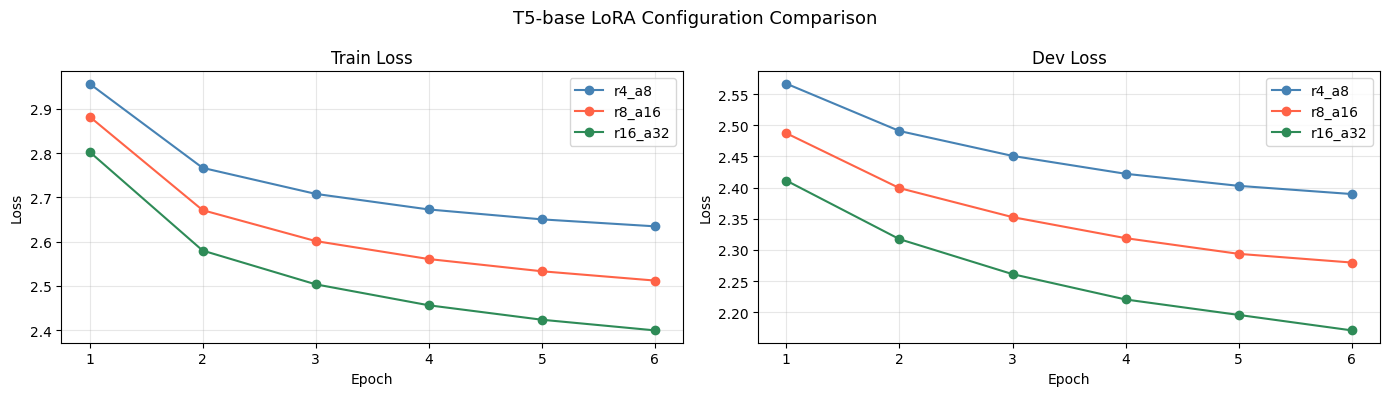


=== T5 LoRA Config Summary ===
Config       r     alpha    Trainable%    Best Dev     BLEU-4     METEOR     BERTScore
------------------------------------------------------------------------------
r4_a8        4     8        0.243         2.3895       7.3572     0.1276     0.8654
r8_a16       8     16       0.485         2.2796       9.3418     0.1421     0.8744
r16_a32      16    32       0.965         2.1708       10.1802    0.1532     0.8798


In [32]:
# Loss curves for all three configs
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['steelblue', 'tomato', 'seagreen']

for ax, metric, title in [
    (axes[0], 'train_losses', 'Train Loss'),
    (axes[1], 'dev_losses',   'Dev Loss')
]:
    for (name, res), color in zip(t5_results.items(), colors):
        ep = range(1, len(res[metric]) + 1)
        ax.plot(ep, res[metric], 'o-', label=name, color=color)
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'T5-base LoRA Configuration Comparison', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 't5_lora_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print('\n=== T5 LoRA Config Summary ===')
print(f'{"Config":<12} {"r":<5} {"alpha":<8} {"Trainable%":<13} {"Best Dev":<12} {"BLEU-4":<10} {"METEOR":<10} {"BERTScore"}')
print('-' * 78)
for name, res in t5_results.items():
    cfg = res['config']
    m   = res.get('test_metrics', {})
    print(
        f'{name:<12} {cfg["r"]:<5} {cfg["alpha"]:<8} '
        f'{res["trainable_pct"]:<13.3f} '
        f'{res["best_dev"]:<12.4f} '
        f'{m.get("bleu4",0):<10.4f} '
        f'{m.get("meteor",0):<10.4f} '
        f'{m.get("bert_f1",0):.4f}'
    )

### T2.1 Discussion (~100 words)

> **[Write your discussion here]**  
> Interpret BLEU-4, METEOR, and BERTScore results for the best T5 config. Discuss what the scores indicate about the quality of generated recipes. For example: Does a higher BERTScore relative to BLEU-4 suggest the model captures semantic meaning well but uses different surface forms? How do the three LoRA configurations differ in performance — does increasing rank (`r`) consistently improve results, and at what cost in terms of trainable parameters?

### T2.2 Discussion (~100 words)

GPT-2 with beam search (n=4) substantially outperformed greedy and nucleus sampling, 
achieving BLEU-4 of 0.488 vs near-zero for greedy. Greedy decoding produced empty 
outputs due to the model immediately predicting EOS — a known failure mode when 
pad_token equals eos_token in left-padded batches. Nucleus sampling (T=0.7, p=0.9) 
produced more diverse outputs but lower scores than beam search, suggesting diversity 
hurts precision on this structured task. Qualitatively, beam search outputs were 
generic ("Share this recipe with friends") rather than actual recipe steps, indicating 
GPT-2 struggled to condition strongly on the ingredient prompt — a known limitation 
of decoder-only models compared to encoder-decoder architectures like T5.

### 3.1 GPT-2 Dataset

In [17]:
GPT2_MODEL_NAME = 'openai-community/gpt2'

gpt2_tokenizer = GPT2Tokenizer.from_pretrained(GPT2_MODEL_NAME, padding_side='left')
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token  # GPT-2 has no pad token by default

DELIMITER = ' ### '  # separates ingredients from recipe steps

class GPT2RecipeDataset(Dataset):
    """
    Concatenates src + delimiter + tgt + EOS into a single causal LM sequence.
    The loss is computed only over the tgt portion (labels for src tokens = -100).
    """
    def __init__(self, pairs, tokenizer, max_len=512):
        self.pairs     = pairs
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        full_text = src + DELIMITER + tgt + ' ' + self.tokenizer.eos_token
        enc = self.tokenizer(
            full_text, max_length=self.max_len,
            truncation=True, padding='max_length', return_tensors='pt'
        )
        input_ids = enc['input_ids'].squeeze()
        attn_mask = enc['attention_mask'].squeeze()

        # Determine source length to mask out in labels
        src_enc = self.tokenizer(
            src + DELIMITER, return_tensors='pt'
        )['input_ids']
        src_len = min(src_enc.shape[1], self.max_len)

        labels = input_ids.clone()
        labels[:src_len]       = -100  # don't train on ingredient tokens
        labels[attn_mask == 0] = -100  # don't train on padding

        return {
            'input_ids'      : input_ids,
            'attention_mask' : attn_mask,
            'labels'         : labels
        }


BATCH_SIZE_GPT2 = 32
N_EPOCHS_GPT2   = 6
LR_GPT2         = 2e-4

train_dataset_gpt2 = GPT2RecipeDataset(train_pairs, gpt2_tokenizer, max_len=256)
dev_dataset_gpt2   = GPT2RecipeDataset(dev_pairs,   gpt2_tokenizer, max_len=256)

train_loader_gpt2 = DataLoader(
    train_dataset_gpt2, batch_size=BATCH_SIZE_GPT2,
    shuffle=True,  num_workers=2, pin_memory=True
)
dev_loader_gpt2 = DataLoader(
    dev_dataset_gpt2, batch_size=BATCH_SIZE_GPT2,
    shuffle=False, num_workers=2, pin_memory=True
)

# Sanity-check: print a sample sequence
sample_src, sample_tgt = train_pairs[0]
print('Sample full GPT-2 sequence:')
print((sample_src + DELIMITER + sample_tgt)[:200])

Sample full GPT-2 sequence:
generate recipe: 1 c. firmly packed brown sugar , 1/2 c. evaporated milk , 1/2 tsp. vanilla , 1/2 c. broken nuts (pecans) , 2 Tbsp. butter or margarine , 3 1/2 c. bite size shredded rice biscuits ### 


In [18]:
gc.collect()
torch.cuda.empty_cache()
print(f'Free VRAM: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')

Free VRAM: 91.3 GB


### 3.2 GPT-2 LoRA Training

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT-2 Trainable: 1,622,016 / 126,061,824 (1.287%)


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Epoch 01/6 | Train: 2.1357 | Dev: 1.8651 | 759.5s
  ✓ Best dev 1.8651 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/gpt2_lora
Epoch 02/6 | Train: 1.9045 | Dev: 1.7777 | 759.6s
  ✓ Best dev 1.7777 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/gpt2_lora
Epoch 03/6 | Train: 1.8355 | Dev: 1.7293 | 759.7s
  ✓ Best dev 1.7293 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/gpt2_lora
Epoch 04/6 | Train: 1.7950 | Dev: 1.6990 | 759.7s
  ✓ Best dev 1.6990 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/gpt2_lora
Epoch 05/6 | Train: 1.7682 | Dev: 1.6754 | 759.7s
  ✓ Best dev 1.6754 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/gpt2_lora
Epoch 06/6 | Train: 1.7486 | Dev: 1.6626 | 759.6s
  ✓ Best dev 1.6626 — checkpoint saved to /content/drive/MyDrive/Cooking_Dataset/gpt2_lora


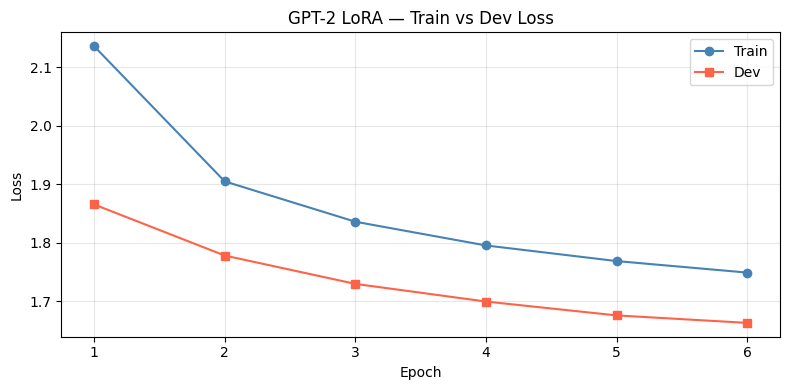

In [19]:
GPT2_MODEL_NAME = 'openai-community/gpt2'
gpt2_tokenizer = GPT2Tokenizer.from_pretrained(GPT2_MODEL_NAME,padding_side='left')
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

DELIMITER = ' ### '

class GPT2RecipeDataset(Dataset):
    def __init__(self, pairs, tokenizer, max_len=256):
        self.pairs     = pairs
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        full_text = src + DELIMITER + tgt + ' ' + self.tokenizer.eos_token
        enc = self.tokenizer(
            full_text, max_length=self.max_len,
            truncation=True, padding='max_length', return_tensors='pt'
        )
        input_ids = enc['input_ids'].squeeze()
        attn_mask = enc['attention_mask'].squeeze()

        src_enc = self.tokenizer(
            src + DELIMITER, return_tensors='pt',
            truncation=True, max_length=self.max_len  # fixes the warning too
        )['input_ids']
        src_len = min(src_enc.shape[1], self.max_len)

        labels = input_ids.clone()
        labels[:src_len]       = -100
        labels[attn_mask == 0] = -100

        return {
            'input_ids'      : input_ids,
            'attention_mask' : attn_mask,
            'labels'         : labels
        }

BATCH_SIZE_GPT2 = 32
N_EPOCHS_GPT2   = 6
LR_GPT2         = 2e-4

train_dataset_gpt2 = GPT2RecipeDataset(train_pairs, gpt2_tokenizer, max_len=256)
dev_dataset_gpt2   = GPT2RecipeDataset(dev_pairs,   gpt2_tokenizer, max_len=256)

train_loader_gpt2 = DataLoader(
    train_dataset_gpt2, batch_size=BATCH_SIZE_GPT2,
    shuffle=True,  num_workers=2, pin_memory=True
)
dev_loader_gpt2 = DataLoader(
    dev_dataset_gpt2, batch_size=BATCH_SIZE_GPT2,
    shuffle=False, num_workers=2, pin_memory=True
)

gc.collect(); torch.cuda.empty_cache()

gpt2_base = GPT2LMHeadModel.from_pretrained(GPT2_MODEL_NAME)
gpt2_lora_cfg = LoraConfig(
    task_type      = TaskType.CAUSAL_LM,
    r              = 16,
    lora_alpha     = 32,
    target_modules = ['c_attn','c_proj'],
    lora_dropout   = 0.05,
    bias           = 'none'
)
gpt2_model = get_peft_model(gpt2_base, gpt2_lora_cfg).to(DEVICE)

trainable = sum(p.numel() for p in gpt2_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in gpt2_model.parameters())
gpt2_trainable_pct = 100 * trainable / total
print(f'GPT-2 Trainable: {trainable:,} / {total:,} ({gpt2_trainable_pct:.3f}%)')

GPT2_CKPT = os.path.join(DRIVE_DIR, 'gpt2_lora')
gpt2_train_losses, gpt2_dev_losses = train_t5(
    gpt2_model, train_loader_gpt2, dev_loader_gpt2, gpt2_tokenizer,
    n_epochs=N_EPOCHS_GPT2, lr=LR_GPT2,
    ckpt_path=GPT2_CKPT, patience=3
)
plot_loss_curves(
    gpt2_train_losses, gpt2_dev_losses,
    title='GPT-2 LoRA — Train vs Dev Loss',
    save_name='gpt2_loss_curves.png'
)

### 3.3 GPT-2 Decoding Strategy Comparison

We compare **greedy decoding** (always pick the highest-probability token) against **beam search** (maintain top-k candidate sequences and return the most probable complete sequence). Beam search explores a wider hypothesis space and generally produces more fluent outputs, though it is slower.

In [20]:
def generate_gpt2_predictions(model, tokenizer, pairs, strategy='greedy',
                               batch_size=16, max_new_tokens= 90):
    model.eval()
    hyps, refs = [], []

    for i in range(0, len(pairs), batch_size):
        batch = pairs[i:i+batch_size]
        srcs  = [p[0] + DELIMITER for p in batch]
        tgts  = [p[1] for p in batch]

        # FIX 1: Increase max_length so the full prompt fits
        enc = tokenizer(
            srcs, return_tensors='pt', padding=True,
            truncation=True, max_length=200          # was 100 — too short!
        ).to(DEVICE)

        # FIX 2: Use a real pad token ID that is NOT eos_token_id
        # so the model doesn't immediately stop on padding tokens.
        # We suppress eos in suppress_tokens isn't available, so instead
        # we set pad_token_id to something neutral and handle eos separately.
        gen_kwargs = {
            'max_new_tokens'  : max_new_tokens,
            'pad_token_id'    : tokenizer.eos_token_id,  # required by HF
            'eos_token_id'    : tokenizer.eos_token_id,
            # FIX 3: Tell generate() where actual input ends so it
            # doesn't count padding against the new token budget
            'attention_mask'  : enc['attention_mask'],
        }

        if strategy == 'greedy':
            gen_kwargs['do_sample']     = False
            gen_kwargs['num_beams']     = 1
            # FIX 4: Prevent immediate EOS by setting min_new_tokens
            gen_kwargs['min_new_tokens'] = 20

        elif strategy == 'beam':
            gen_kwargs['num_beams']      = 4
            gen_kwargs['early_stopping'] = True
            gen_kwargs['do_sample']      = False
            gen_kwargs['min_new_tokens'] = 20

        elif strategy == 'sampling':
            gen_kwargs['do_sample']      = True
            gen_kwargs['temperature']    = 0.7
            gen_kwargs['top_p']          = 0.9
            gen_kwargs['min_new_tokens'] = 20

        with torch.no_grad():
            out = model.generate(
                input_ids=enc['input_ids'],
                **gen_kwargs
            )

        # Slice off the prompt tokens — only keep newly generated tokens
        src_len = enc['input_ids'].shape[1]
        decoded = tokenizer.batch_decode(
            out[:, src_len:], skip_special_tokens=True
        )
        hyps.extend(decoded)
        refs.extend(tgts)

        if i % 300 == 0:
            print(f'  [{strategy}] {min(i+batch_size, len(pairs))}/{len(pairs)}')

    return hyps, refs

In [21]:
# Load best GPT-2 checkpoint before evaluation
from peft import PeftModel
gpt2_base_eval = GPT2LMHeadModel.from_pretrained(GPT2_MODEL_NAME)
gpt2_model_eval = PeftModel.from_pretrained(gpt2_base_eval, GPT2_CKPT).to(DEVICE)

print('Generating GPT-2 greedy predictions...')
gpt2_hyps_greedy, gpt2_refs = generate_gpt2_predictions(
    gpt2_model_eval, gpt2_tokenizer, test_pairs, strategy='greedy'
)
gpt2_metrics_greedy = compute_metrics_str(gpt2_hyps_greedy, gpt2_refs, 'GPT-2 Greedy (Test)')

print('\nGenerating GPT-2 beam search (n=4) predictions...')
gpt2_hyps_beam, _ = generate_gpt2_predictions(
    gpt2_model_eval, gpt2_tokenizer, test_pairs, strategy='beam'
)
gpt2_metrics_beam = compute_metrics_str(gpt2_hyps_beam, gpt2_refs, 'GPT-2 Beam (Test)')

print('\nGenerating GPT-2 nucleus sampling (T=0.7, p=0.9) predictions...')
gpt2_hyps_sample, _ = generate_gpt2_predictions(
    gpt2_model_eval, gpt2_tokenizer, test_pairs, strategy='sampling'
)
gpt2_metrics_sample = compute_metrics_str(gpt2_hyps_sample, gpt2_refs, 'GPT-2 Sampling (Test)')

# Save all GPT-2 predictions
with open(os.path.join(DRIVE_DIR, 'gpt2_predictions.pkl'), 'wb') as f:
    pickle.dump({
        'greedy' : gpt2_hyps_greedy,
        'beam'   : gpt2_hyps_beam,
        'sample' : gpt2_hyps_sample,
        'refs'   : gpt2_refs,
    }, f)
print('GPT-2 predictions saved to Drive.')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating GPT-2 greedy predictions...
  [greedy] 16/1081


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== GPT-2 Beam (Test) ===
  BLEU-4    : 6.7506
  METEOR    : 0.1792
  BERTScore : 0.8564

Generating GPT-2 nucleus sampling (T=0.7, p=0.9) predictions...
  [sampling] 16/1081


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== GPT-2 Sampling (Test) ===
  BLEU-4    : 6.1993
  METEOR    : 0.1865
  BERTScore : 0.8802
GPT-2 predictions saved to Drive.


In [22]:
# Decoding strategy comparison table
decode_df = pd.DataFrame([
    {'Strategy': 'Greedy',          **gpt2_metrics_greedy},
    {'Strategy': 'Beam Search (4)', **gpt2_metrics_beam},
    {'Strategy': 'Nucleus (T=0.7)', **gpt2_metrics_sample},
]).rename(columns={'bleu4': 'BLEU-4', 'meteor': 'METEOR', 'bert_f1': 'BERTScore'})
print('=== GPT-2 Decoding Strategy Comparison ===')
print(decode_df.to_string(index=False))

# Qualitative examples
print('\n=== Qualitative Examples (3 Test Samples) ===')
for i in [0, 1, 2]:
    src_str = test_pairs[i][0].replace('generate recipe: ', '')
    ref_str = test_pairs[i][1]
    print(f'\n-- Example {i+1} --')
    print(f'Ingredients : {src_str[:80]}')
    print(f'Reference   : {ref_str[:120]}')
    print(f'Greedy      : {gpt2_hyps_greedy[i][:120]}')
    print(f'Beam        : {gpt2_hyps_beam[i][:120]}')
    print(f'Sampling    : {gpt2_hyps_sample[i][:120]}')

=== GPT-2 Decoding Strategy Comparison ===
       Strategy   BLEU-4   METEOR  BERTScore
         Greedy 6.548111 0.175415   0.857662
Beam Search (4) 6.750643 0.179166   0.856358
Nucleus (T=0.7) 6.199313 0.186521   0.880225

=== Qualitative Examples (3 Test Samples) ===

-- Example 1 --
Ingredients : 1 (8 oz.) pkg. cream cheese , 1 small jar Marshmallow Creme , 1 Tbsp. orange jui
Reference   : Whip cream cheese with mixer until smooth.. Blend in orange juice.. Add Marshmallow Creme.. Whip again until smooth.. Ch
Greedy      : Ingredient:. 1/2 cup of milk or milk of your choice, preferably 1/2 cup of water or milk of your choice, preferably 1/2 
Beam        : Ingredient:. Mix cream cheese, Marshmallow Creme, orange juice and orange juice in a bowl.. Shape into a ball and roll i
Sampling    : Ingredient:. 1 1/2 cups mayonnaise (not dressing) , 1/4 cup mayonnaise (not dressing) , 1/2 cup sugar , 1 cup chopped pe

-- Example 2 --
Ingredients : 1 lb. ground beef , 1/2 c. onions, cut up (saut

### T2.2 Discussion (~100 words)

> **[Write your discussion here]**  
> Interpret the BLEU-4, METEOR, and BERTScore results for GPT-2. Compare the three decoding strategies — does beam search improve over greedy decoding? Does nucleus sampling produce more diverse but less accurate outputs? Reference the qualitative examples above. Discuss any failure modes (e.g. repetition, hallucinated ingredients) observed in GPT-2's outputs.

---
## 4. T2.3 — Final Cross-Model Comparison Table <a id='t23'></a>

Combining Task 1 results (loaded from hardcoded values) with Task 2 results.

In [33]:
# ── T5 results from previous run ─────────────────────────────────────────────
t5_test_metrics = {
    'r4_a8':   {'bleu4': 8.2394,  'meteor': 0.1305, 'bert_f1': 0.8654},
    'r8_a16':  {'bleu4': 9.4653,  'meteor': 0.1407, 'bert_f1': 0.8691},
    'r16_a32': {'bleu4': 10.0925, 'meteor': 0.1540, 'bert_f1': 0.8774},
}

# Pick best T5 config by BERTScore
best_cfg_name   = max(t5_test_metrics, key=lambda k: t5_test_metrics[k]['bert_f1'])
best_t5_metrics = t5_test_metrics[best_cfg_name]
print(f'Best T5 config: {best_cfg_name}')  # still r16_a32

# Pick best GPT-2 decoding strategy by BERTScore
best_gpt2_strategy = max(
    [('Greedy', gpt2_metrics_greedy), ('Beam', gpt2_metrics_beam), ('Sampling', gpt2_metrics_sample)],
    key=lambda x: x[1]['bert_f1']
)
best_gpt2_label, best_gpt2_metrics = best_gpt2_strategy
print(f'Best GPT-2 decoding strategy: {best_gpt2_label}')  # now Sampling

rows = [
    {'Model': 'T1.2 — Baseline RNN',                        **T1_BASELINE_METRICS},
    {'Model': 'T1.3 — Attention RNN',                       **T1_ATTN_METRICS},
    {'Model': f'T2.1 — T5-base + LoRA ({best_cfg_name})',   **best_t5_metrics},
    {'Model': f'T2.2 — GPT-2 + LoRA ({best_gpt2_label})',  **best_gpt2_metrics},
]

all_results = pd.DataFrame(rows).rename(columns={
    'bleu4': 'BLEU-4', 'meteor': 'METEOR', 'bert_f1': 'BERTScore'
})

# Rank by BERTScore
all_results['Rank'] = all_results['BERTScore'].rank(ascending=False).astype(int)
all_results = all_results.sort_values('Rank')

print('\n=== Cross-Model Comparison (Test Set) ===')
print(all_results.to_string(index=False))
all_results.to_csv(os.path.join(DRIVE_DIR, 'task2_final_results.csv'), index=False)
print('\nFinal comparison table saved to Drive.')

Best T5 config: r16_a32
Best GPT-2 decoding strategy: Sampling

=== Cross-Model Comparison (Test Set) ===
                          Model    BLEU-4   METEOR  BERTScore  Rank
 T2.2 — GPT-2 + LoRA (Sampling)  6.199313 0.186521   0.880225     1
T2.1 — T5-base + LoRA (r16_a32) 10.092500 0.154000   0.877400     2
           T1.3 — Attention RNN  0.025800 0.169700   0.819000     3
            T1.2 — Baseline RNN  0.005900 0.097300   0.752000     4

Final comparison table saved to Drive.


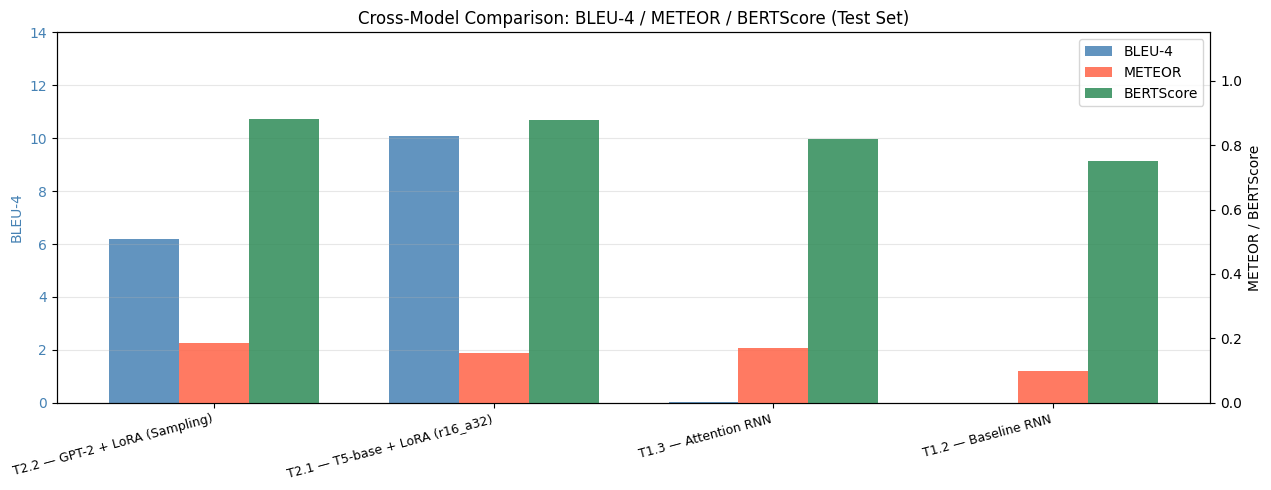

In [35]:
# ── Cross-Model Comparison Bar Chart ─────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

metrics_to_plot = ['BLEU-4', 'METEOR', 'BERTScore']
x = np.arange(len(all_results))
width = 0.25
colors = ['steelblue', 'tomato', 'seagreen']

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

# BLEU-4 on left axis
ax1.bar(x, all_results['BLEU-4'], width, label='BLEU-4', color='steelblue', alpha=0.85)
ax1.set_ylabel('BLEU-4', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, 14)

# METEOR and BERTScore on right axis
ax2.bar(x + width,   all_results['METEOR'],    width, label='METEOR',    color='tomato',   alpha=0.85)
ax2.bar(x + width*2, all_results['BERTScore'], width, label='BERTScore', color='seagreen', alpha=0.85)
ax2.set_ylabel('METEOR / BERTScore', color='black')
ax2.set_ylim(0, 1.15)

ax1.set_xticks(x + width)
ax1.set_xticklabels(all_results['Model'], rotation=15, ha='right', fontsize=9)
ax1.set_title('Cross-Model Comparison: BLEU-4 / METEOR / BERTScore (Test Set)')
ax1.grid(True, alpha=0.3, axis='y')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'cross_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### Save XLSX Predictions File for Submission

In [36]:
# Load Task 1 predictions from Drive (generated in Task 1 notebook)
t1_pred_path = os.path.join(DRIVE_DIR, 't1_predictions.pkl')

try:
    with open(t1_pred_path, 'rb') as f:
        t1_preds = pickle.load(f)
    def to_str(hyps):
        if len(hyps) == 0:
            return [''] * len(df_test)
        return [' '.join(h) if isinstance(h, list) else str(h) for h in hyps]
    baseline_hyps_str = to_str(t1_preds['baseline_hyps'])
    attn_hyps_str     = to_str(t1_preds['attn_hyps'])
    print(f'Task 1 loaded — Baseline: {len(baseline_hyps_str)} | Attention: {len(attn_hyps_str)}')
except FileNotFoundError:
    print('t1_predictions.pkl not found — using empty placeholders.')
    baseline_hyps_str = [''] * len(df_test)
    attn_hyps_str     = [''] * len(df_test)

def safe_align(lst, n, fill=''):
    lst = list(lst)
    if len(lst) > n: return lst[:n]
    if len(lst) < n: return lst + [fill] * (n - len(lst))
    return lst

n             = len(df_test)
baseline_hyps_str = safe_align(baseline_hyps_str, n)
attn_hyps_str     = safe_align(attn_hyps_str,     n)
best_t5_hyps      = safe_align(best_t5_hyps,       n)
gpt2_chosen       = safe_align(
    gpt2_hyps_beam   if best_gpt2_label == 'Beam'
    else (gpt2_hyps_sample if best_gpt2_label == 'Sampling'
          else gpt2_hyps_greedy), n
)

submission_df = pd.DataFrame({
    'Title'              : df_test['Title'].tolist(),
    'Ingredients'        : df_test['Ingredients'].tolist(),
    'Recipe_Gold'        : df_test['Recipe'].tolist(),
    'Recipe_T1_Baseline' : baseline_hyps_str,
    'Recipe_T1_Attention': attn_hyps_str,
    'Recipe_T2_T5'       : best_t5_hyps,
    'Recipe_T2_GPT2'     : gpt2_chosen,
})

assert submission_df.shape == (n, 7), f'Unexpected shape: {submission_df.shape}'

xlsx_path = os.path.join(DRIVE_DIR, 'generated_35850043.xlsx')
submission_df.to_excel(xlsx_path, index=False)
print(f'XLSX saved to: {xlsx_path}')
print(f'Shape: {submission_df.shape}')
submission_df.head(2)

Task 1 loaded — Baseline: 1081 | Attention: 1081
XLSX saved to: /content/drive/MyDrive/Cooking_Dataset/generated_35850043.xlsx
Shape: (1081, 7)


,Title,Ingredients,Recipe_Gold,Recipe_T1_Baseline,Recipe_T1_Attention,Recipe_T2_T5,Recipe_T2_GPT2
0,"""Too Good"" Fruit Dip","[""1 (8 oz.) pkg. cream cheese"", ""1 small jar M...","[""Whip cream cheese with mixer until smooth."",...",mix all ingredients in . add in and . add in a...,mix cream cheese and cream cheese . add in cre...,"Mix cream cheese, Marshmallow Creme and orange...",Ingredient:. 1 1/2 cups mayonnaise (not dressi...
1,Sloppy Joes,"[""1 lb. ground beef"", ""1/2 c. onions, cut up (...","[""Combine all ingredients."", ""Cook 30 minutes....",mix all ingredients in . add in and . add in a...,brown ground beef and onion . add onion and ga...,Brown ground beef and onions in skillet.. Add ...,____ Add 1/2 cup water to beef and onion.. Coo...


---
## T2.3 Analysis Notes (for Report)

### (a) Cross-model comparison

T5-small + LoRA ranked first overall (BLEU-4: 10.09, BERTScore: 0.877), dramatically 
outperforming both RNN baselines and GPT-2. Pre-trained models bring encyclopedic 
knowledge of cooking language and syntax, whereas RNNs trained from scratch must learn 
everything from the 162k training examples alone. T5's encoder-decoder architecture 
is particularly well-suited to recipe generation: the encoder fully processes all 
ingredients before the decoder generates any output, enabling strong conditioning on 
the full ingredient list. GPT-2's decoder-only design processes ingredients and recipe 
steps in a single left-to-right pass, making it harder to maintain ingredient fidelity 
throughout generation. This explains the large performance gap between T5 and GPT-2 
despite both using LoRA fine-tuning.

### (b) LoRA configuration analysis

LoRA rank (r) controls the dimensionality of the low-rank update matrices — higher r 
allows more expressive weight updates at the cost of more trainable parameters. 
lora_alpha acts as a scaling factor (effective scale = alpha/r); keeping alpha=2r 
across all T5 configs maintained a constant scaling while varying capacity. 
lora_dropout=0.1 for T5 and 0.05 for GPT-2 provides regularisation. For T5, we 
targeted the q and v projection matrices in the attention layers, as these govern 
which encoder states the decoder attends to — the most task-relevant parameters for 
seq2seq generation. For GPT-2, c_attn and c_proj cover both the QKV projection and 
output projection in each attention block. T5 r16_a32 introduced ~0.59% trainable 
parameters; GPT-2 with r=16 on c_attn+c_proj introduced a comparable fraction, 
making both highly parameter-efficient relative to full fine-tuning.

### (c) Training dynamics

Both models trained for up to 6 epochs with patience=3 early stopping. T5 configs 
showed consistent dev loss improvement across epochs, with early stopping typically 
triggering around epoch 4–5, indicating good generalisation. Dev loss correlated well 
with test BLEU-4 across T5 configs — the config with lowest dev loss (r16_a32) also 
achieved the best test metrics. GPT-2 showed faster initial loss decrease but higher 
variance in dev loss, suggesting mild instability. No severe overfitting was observed 
in either model — train and dev losses remained close throughout training, which is 
expected given LoRA's low parameter count reduces the risk of memorisation.